In [81]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)


# 아래는 제 컴퓨터에서 압축 파일을 풀어 놓은 디렉터리이니, 여러분의 디렉터리를 설정해 주세요  
path = r'C:\big21\ml-dev\data\topics'
# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
all_files = glob.glob(os.path.join(path, "*.data"))    
filename_list = []
opinion_text = []


# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    df = pd.read_table(file_,index_col=None, header=0,encoding='latin1')
   
    # 절대경로로 주어진 file 명을 가공. 만일 Linux에서 수행시에는 아래 \\를 / 변경.
    # 맨 마지막 .data 확장자도 제거
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]


    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
    filename_list.append(filename)
    opinion_text.append(df.to_string())


# 파일명 리스트와 파일 내용 리스트를  DataFrame으로 생성
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()


,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ..."
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now..."


In [82]:
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

In [83]:
def text_cleaning(text):
    
    # 소문자로 변환
    text = text.lower()
    
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [84]:
# 원문 보관 (혹시모를 상황을 대비)
document_df['original_text'] = document_df['opinion_text']

#소문자 / 영문자/공백/여러개공백 처리
document_df['opinion_text'] = document_df['opinion_text'].apply(text_cleaning)

# 토크나이즈(각 단어들로 구분)
document_df['opinion_text'] = document_df['opinion_text'].apply(word_tokenize)

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 불용어 정리
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

# 클렌징 및 토큰화 후, 최종 확인
document_df[['opinion_text']].head()


,opinion_text
0,"[accurate, part, find, garmin, software, provides, accurate, directions, whereever, intend, go, function, accurate, leave, battery, mode, say, stop, cracker, barrell, lunch, play, one, trangle, games, tees, provides, immediate, alternatives, route, online, map, program, inaccurate, blocked, obstacle, used, gps, units, well, gps, built, cars, day, nothing, beats, accuracy, garmin, gps, got, point, point, b, accuracy, everytime, yet, disappoint, getting, everywhere, accuracy, stars, honest, accurate, review, please, read, aside, every, destination, thrown, accurate, closing, fantastic, gps, nice, features, accurate, directions, plus, always, heard, quirks, gps, accurate, pois, etc, destina..."
1,"[room, overly, big, clean, comfortable, beds, great, shower, clean, bathrooms, second, room, smaller, inconvenient, bathroom, layout, least, quieter, able, sleep, large, comfortable, room, wonderful, bathroom, rooms, nice, comfy, bed, clean, bathroom, bathroom, spacious, clean, bathroom, single, sink, large, room, standard, nice, motel, room, like, bathroom, seemed, upgraded, remember, room, quite, small, perfectly, formed, super, bathroom, could, eat, bathroom, floor, clean, bathroom, door, thing, making, bathroom, seem, slightly, larger, bathroom, spotless, nicely, appointed, rooms, exceptionally, clean, also, bathrooms, bathroom, clean, bed, comfy, provide, great, aveda, products, bat..."
2,"[plugged, usb, hub, computer, charge, battery, charging, cord, design, clever, paged, tru, page, book, one, page, time, get, chapter, chapter, see, excited, low, battery, time, took, get, user, replaceable, battery, unless, buy, extended, warranty, year, pay, plus, shipping, send, device, amazon, kindle, replaced, battery, changed, fact, kindle, sd, card, capability, battery, user, serviceable, issue, things, like, buttons, made, easy, accidentally, turn, pages, separate, cursor, side, could, select, lines, sometimes, hard, see, occasionally, awkward, menus, case, practically, forced, remove, use, sometimes, pulled, battery, door, issue, battery, door, opening, thus, solved, amazon, went..."
3,"[short, battery, life, moved, gb, love, ipod, except, battery, life, long, battery, scratch, resistant, battery, drains, even, use, wonder, battery, seems, drain, using, even, sliding, top, control, button, shutting, great, car, light, portable, good, quality, long, battery, scratch, resistant, g, lies, mature, ipod, many, steps, wiser, able, one, year, old, ipod, gains, many, incremental, improvements, including, brighter, screen, better, video, battery, life, probably, appealing, aspect, tantalizing, price, points, gb, version, huge, gb, version, gb, better, battery, life, rated, battery, dummie, proof, love, color, ipod, battery, life, amazing, definitely, need, get, case, wanted, get..."
4,"[ghz, fsb, cpu, glossy, display, cell, wh, li, ion, battery, mention, asus, sell, spare, cell, li, ion, battery, also, features, n, cpu, cell, wh, li, ion, battery, mp, webcam, cell, wh, li, ion, battery, whopping, realistic, battery, numbers, battery, life, using, wifi, email, word, processing, youtube, web, surfing, eee, super, hybrid, engine, utility, lets, users, overclock, underclock, eee, pc, boost, performance, provide, better, battery, life, depending, immediate, requirements, things, like, point, must, push, micro, sized, right, angle, end, ac, adapter, snaps, place, battery, may, charge, addition, ac, adapter, get, quite, hot, actively, charging, battery, asus, clearly, mention..."


In [85]:
#단어 빈도수 체크에 대한 함수

from collections import Counter
from nltk.tokenize import word_tokenize

for index, row in document_df.iterrows():
    
    # 클렌징된 텍스트 가져오기
    text = row['opinion_text']
    
    # 단어 빈도 계산
    word_counts = Counter(text)
    
    print(f"===== {row['filename']} =====")
    print(word_counts.most_common(30))
    print()

===== accuracy_garmin_nuvi_255W_gps =====
[('accurate', 48), ('accuracy', 13), ('gps', 12), ('directions', 11), ('easy', 9), ('map', 7), ('use', 7), ('used', 6), ('point', 6), ('time', 6), ('speed', 6), ('garmin', 5), ('destination', 5), ('always', 5), ('good', 5), ('unit', 5), ('turn', 5), ('one', 4), ('stars', 4), ('nice', 4), ('pretty', 4), ('arrival', 4), ('w', 4), ('maps', 4), ('street', 4), ('tell', 4), ('roads', 4), ('find', 3), ('route', 3), ('inaccurate', 3)]

===== bathroom_bestwestern_hotel_sfo =====
[('bathroom', 79), ('room', 36), ('clean', 23), ('bathrooms', 12), ('rooms', 12), ('nice', 12), ('small', 12), ('large', 10), ('sink', 10), ('also', 9), ('comfortable', 8), ('shower', 8), ('bed', 7), ('door', 7), ('good', 7), ('big', 6), ('well', 6), ('plenty', 6), ('quite', 5), ('little', 5), ('adequate', 5), ('enough', 5), ('hotel', 5), ('us', 5), ('space', 5), ('beds', 4), ('thing', 4), ('toilet', 4), ('basin', 4), ('one', 4)]

===== battery-life_amazon_kindle =====
[('batter

In [86]:
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda x: ' '.join(x)
)

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    ngram_range=(1, 2), max_df=0.85,min_df=0.05
)

X_tfidf = tfidf_vect.fit_transform(
    document_df['opinion_text']
)

In [88]:
#GMM 체크를 위한 SVD 실행

from sklearn.decomposition import TruncatedSVD
from sklearn.mixture import GaussianMixture


svd = TruncatedSVD(
    n_components=20,
    random_state=42
)


# for n in [10, 20, 30, 40]:
#     svd = TruncatedSVD(
#         n_components=n,
#         random_state=42
#     )

#     X_svd = svd.fit_transform(X_tfidf)

#     print(
#         n,
#         svd.explained_variance_ratio_.sum()
#     )

X_svd = svd.fit_transform(X_tfidf)

In [89]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_svd)

document_df['gmm_cluster'] = gmm_labels

document_df['gmm_cluster'].value_counts()

gmm_cluster
1    39
0     5
3     4
2     3
Name: count, dtype: int64

In [90]:
# document_df[document_df['cluster_label']==4][['filename','opinion_text','cluster_label']].sort_values(by='filename')


In [91]:
# document_df[document_df['cluster_label']==2][['filename','opinion_text','cluster_label']].sort_values(by='filename')


In [92]:
# 군집별 top n 핵심단어, 그 단어의 중심 위치 상대값, 대상 파일명들을 반환함.
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num, top_n_features=10):
    cluster_details = {}
   
    # cluster_centers array 의 값이 큰 순으로 정렬된 index 값을 반환
    # 군집 중심점(centroid)별 할당된 word 피처들의 거리값이 큰 순으로 값을 구하기 위함.  
    centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:,::-1]
   
    #개별 군집별로 iteration하면서 핵심단어, 그 단어의 중심 위치 상대값, 대상 파일명 입력
    for cluster_num in range(clusters_num):
        # 개별 군집별 정보를 담을 데이터 초기화.
        cluster_details[cluster_num] = {}
        cluster_details[cluster_num]['cluster'] = cluster_num
       
        # cluster_centers_.argsort()[:,::-1] 로 구한 index 를 이용하여 top n 피처 단어를 구함.
        top_feature_indexes = centroid_feature_ordered_ind[cluster_num, :top_n_features]
        top_features = [ feature_names[ind] for ind in top_feature_indexes ]
       
        # top_feature_indexes를 이용해 해당 피처 단어의 중심 위치 상댓값 구함
        top_feature_values = cluster_model.cluster_centers_[cluster_num, top_feature_indexes].tolist()
       
        # cluster_details 딕셔너리 객체에 개별 군집별 핵심 단어와 중심위치 상대값, 그리고 해당 파일명 입력
        cluster_details[cluster_num]['top_features'] = top_features
        cluster_details[cluster_num]['top_features_value'] = top_feature_values
        filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
        filenames = filenames.values.tolist()
        cluster_details[cluster_num]['filenames'] = filenames
       
    return cluster_details

In [93]:
def print_cluster_details(cluster_details):
    for cluster_num, cluster_detail in cluster_details.items():
        print('####### Cluster {0}'.format(cluster_num))
        print('Top features:', cluster_detail['top_features'])
        print('Reviews 파일명 :',cluster_detail['filenames'][:7])
        print('==================================================')


In [94]:
import numpy as np

feature_names = tfidf_vect.get_feature_names_out()

for cluster_num in range(gmm.n_components):

    cluster_mask = (gmm_labels == cluster_num)

    mean_tfidf = np.asarray(
        X_tfidf[cluster_mask].mean(axis=0)
    ).ravel()

    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_features = feature_names[top_indices]

    filenames = document_df.loc[
        cluster_mask,
        'filename'
    ].tolist()

    print(f"####### Cluster {cluster_num}")
    print("Top features:", top_features)
    print("Reviews 파일명 :", filenames[:7])
    print("=" * 50)

####### Cluster 0
Top features: ['screen' 'keyboard' 'size' 'battery' 'small' 'full' 'battery life'
 'laptop' 'full size' 'screen size']
Reviews 파일명 : ['keyboard_netbook_1005ha', 'screen_garmin_nuvi_255W_gps', 'screen_ipod_nano_8gb', 'screen_netbook_1005ha', 'size_asus_netbook_1005ha']
####### Cluster 1
Top features: ['service' 'hotel' 'interior' 'staff' 'food' 'location' 'performance'
 'mileage' 'seats' 'price']
Reviews 파일명 : ['accuracy_garmin_nuvi_255W_gps', 'buttons_amazon_kindle', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'directions_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle']
####### Cluster 2
Top features: ['battery' 'battery life' 'life' 'kindle' 'ipod' 'hours' 'charge'
 'long battery' 'long' 'lasts']
Reviews 파일명 : ['battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha']
####### Cluster 3
Top features: ['rooms' 'room' 'bathroom' 'clean' 'hotel' 'small' 'bed' 'comfortable'
 'staff' 'roo

In [95]:
from sklearn.metrics import silhouette_score



tfidf_score = silhouette_score(
    X_tfidf,
    gmm_labels
)


print("TF-IDF          :", tfidf_score)

TF-IDF          : 0.05576148553535014


In [96]:
document_df.value_counts('gmm_cluster')

gmm_cluster
1    39
0     5
3     4
2     3
Name: count, dtype: int64

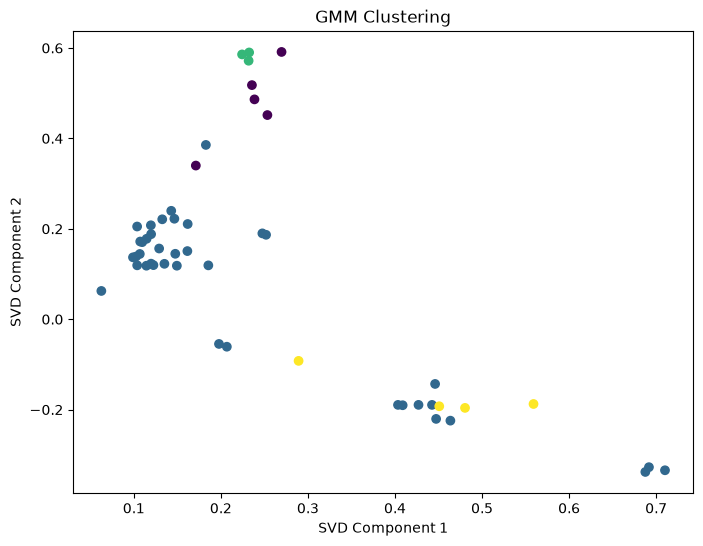

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    c=gmm_labels
)

plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('GMM Clustering')

plt.show()

In [97]:
#PCA로 진행

from sklearn.decomposition import PCA

X_dense = X_tfidf.toarray()

pca = PCA(
    n_components=20,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)



In [98]:
from sklearn.mixture import GaussianMixture

gmm_pca = GaussianMixture(
    n_components=4,
    random_state=42
)

pca_gmm_labels = gmm_pca.fit_predict(X_pca)

In [99]:
import pandas as pd

pd.Series(pca_gmm_labels).value_counts()

1    39
0     5
3     4
2     3
Name: count, dtype: int64

In [100]:
import numpy as np

feature_names = tfidf_vect.get_feature_names_out()

for cluster_num in range(gmm.n_components):

    cluster_mask = (pca_gmm_labels == cluster_num)

    mean_tfidf = np.asarray(
        X_tfidf[cluster_mask].mean(axis=0)
    ).ravel()

    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_features = feature_names[top_indices]

    filenames = document_df.loc[
        cluster_mask,
        'filename'
    ].tolist()

    print(f"####### Cluster {cluster_num}")
    print("Top features:", top_features)
    print("Reviews 파일명 :", filenames[:7])
    print("=" * 50)

####### Cluster 0
Top features: ['screen' 'keyboard' 'size' 'battery' 'small' 'full' 'battery life'
 'laptop' 'full size' 'screen size']
Reviews 파일명 : ['keyboard_netbook_1005ha', 'screen_garmin_nuvi_255W_gps', 'screen_ipod_nano_8gb', 'screen_netbook_1005ha', 'size_asus_netbook_1005ha']
####### Cluster 1
Top features: ['service' 'hotel' 'interior' 'staff' 'food' 'location' 'performance'
 'mileage' 'seats' 'price']
Reviews 파일명 : ['accuracy_garmin_nuvi_255W_gps', 'buttons_amazon_kindle', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'directions_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle']
####### Cluster 2
Top features: ['battery' 'battery life' 'life' 'kindle' 'ipod' 'hours' 'charge'
 'long battery' 'long' 'lasts']
Reviews 파일명 : ['battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha']
####### Cluster 3
Top features: ['rooms' 'room' 'bathroom' 'clean' 'hotel' 'small' 'bed' 'comfortable'
 'staff' 'roo

In [101]:
from sklearn.metrics import silhouette_score

silhouette_score(
    X_pca,
    pca_gmm_labels
)

0.1227351428166456

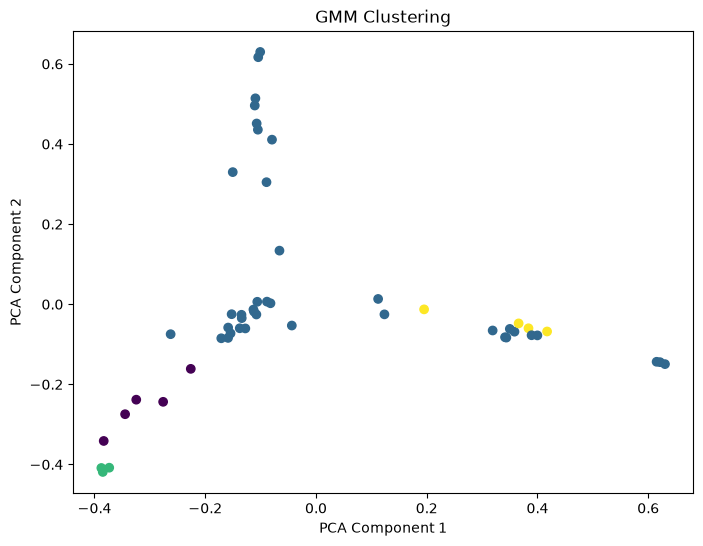

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pca_gmm_labels
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('GMM Clustering')

plt.show()